# Práctica de PCA con `VegaDataset` (coches)

Este notebook muestra paso a paso cómo aplicar **PCA (Principal Component Analysis)** al dataset `cars` de `vega_datasets`.

Se cubre:

- carga del dataset,
- selección y limpieza de variables numéricas,
- **centrado y escalado explícitos** (restando media y dividiendo por desviación típica),
- PCA desde la matriz de covarianzas/correlaciones y con `sklearn`,
- visualización de **autovalores** y **varianza explicada**,
- proyecciones en **1D, 2D y 3D**,
- interpretación de **loadings** (cargas de las componentes).


## 1. Imports


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vega_datasets import data
from sklearn.decomposition import PCA

# Para gráficos 3D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)


## 2. Carga del dataset


In [2]:
cars = data.cars()
cars.head()


,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA


In [3]:
cars.info()


<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Name              406 non-null    str           
 1   Miles_per_Gallon  398 non-null    float64       
 2   Cylinders         406 non-null    int64         
 3   Displacement      406 non-null    float64       
 4   Horsepower        400 non-null    float64       
 5   Weight_in_lbs     406 non-null    int64         
 6   Acceleration      406 non-null    float64       
 7   Year              406 non-null    datetime64[us]
 8   Origin            406 non-null    str           
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 28.7 KB


## 3. Selección de variables numéricas para PCA

Nos quedamos con variables cuantitativas clásicas del problema. Excluimos:

- `Name`: texto,
- `Origin`: categórica,
- `Year`: fecha (la podríamos transformar si quisiéramos, pero aquí la dejamos fuera para centrarnos en PCA sobre variables mecánicas y de consumo).


In [4]:
features = [
    'Miles_per_Gallon',
    'Cylinders',
    'Displacement',
    'Horsepower',
    'Weight_in_lbs',
    'Acceleration',
]

df = cars[features].copy()
df.head()


,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration
0,18.0,8,307.0,130.0,3504,12.0
1,15.0,8,350.0,165.0,3693,11.5
2,18.0,8,318.0,150.0,3436,11.0
3,16.0,8,304.0,150.0,3433,12.0
4,17.0,8,302.0,140.0,3449,10.5


In [5]:
# Valores ausentes por columna
df.isna().sum()


Miles_per_Gallon    8
Cylinders           0
Displacement        0
Horsepower          6
Weight_in_lbs       0
Acceleration        0
dtype: int64

## 4. Limpieza de nulos

PCA no admite valores ausentes. Aquí hacemos la opción más simple para práctica: **eliminar filas con NA**.

En un caso real, también podríamos imputar.


In [6]:
df_clean = df.dropna().reset_index(drop=True)
df_clean.shape


(392, 6)

## 5. Centrado y escalado explícitos

Aquí estandarizamos **a mano**:

\[
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
\]

Usamos la desviación típica muestral (`ddof=1`) para que sea coherente con la matriz de covarianzas que calcula `pandas`.


In [7]:
mu = df_clean.mean(axis=0)
sigma = df_clean.std(axis=0, ddof=1)

Z = (df_clean - mu) / sigma

display(mu)
display(sigma)
Z.head()


Miles_per_Gallon      23.445918
Cylinders              5.471939
Displacement         194.411990
Horsepower           104.469388
Weight_in_lbs       2977.584184
Acceleration          15.541327
dtype: float64

Miles_per_Gallon      7.805007
Cylinders             1.705783
Displacement        104.644004
Horsepower           38.491160
Weight_in_lbs       849.402560
Acceleration          2.758864
dtype: float64

,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration
0,-0.697747,1.482053,1.075915,0.663285,0.619748,-1.283618
1,-1.082115,1.482053,1.486832,1.572585,0.842258,-1.464852
2,-0.697747,1.482053,1.181033,1.182885,0.539692,-1.646086
3,-0.953992,1.482053,1.047246,1.182885,0.536160,-1.283618
4,-0.825870,1.482053,1.028134,0.923085,0.554997,-1.827320


In [8]:
# Comprobación: medias ~ 0 y std ~ 1
check = pd.DataFrame({
    'mean_after_scaling': Z.mean(),
    'std_after_scaling': Z.std(ddof=1)
})
check


,mean_after_scaling,std_after_scaling
Miles_per_Gallon,1.087565e-16,1.0
Cylinders,-7.250436e-17,1.0
Displacement,-5.437827e-17,1.0
Horsepower,-1.631348e-16,1.0
Weight_in_lbs,3.625218e-17,1.0
Acceleration,4.350262e-16,1.0


## 6. Matriz de covarianzas de los datos estandarizados

Como hemos estandarizado, esta matriz coincide conceptualmente con la **matriz de correlaciones** de las variables originales.


In [28]:
S = Z.cov()
S

,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration
Miles_per_Gallon,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329
Cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683
Displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800
Horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196
Weight_in_lbs,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839
Acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000


<Axes: >

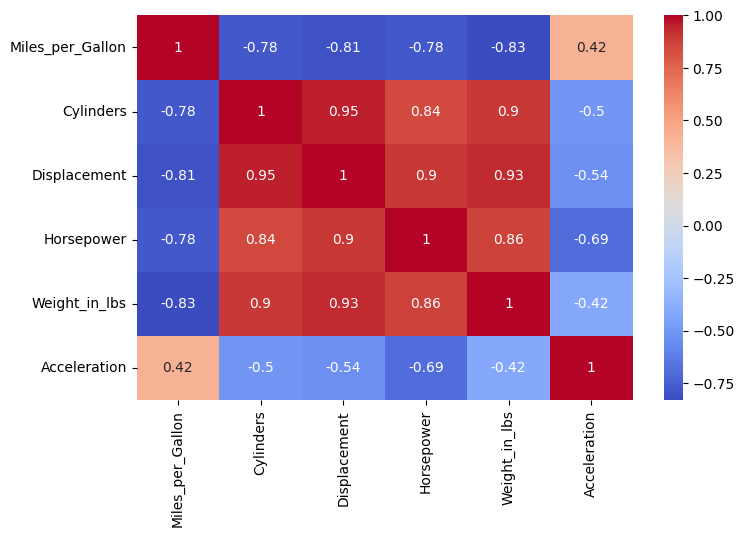

In [33]:
sns.heatmap(S, annot=True, cmap="coolwarm")

## 7. PCA 'a mano' mediante descomposición espectral

Diagonalizamos la matriz simétrica `S` con `np.linalg.eigh`, que devuelve autovalores y autovectores.

Después ordenamos de mayor a menor autovalor.


In [10]:
eigvals, eigvecs = np.linalg.eigh(S.values)

order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

eigvals, eigvecs.shape


(array([4.78826616, 0.72863111, 0.25846732, 0.12517701, 0.0631764 ,
        0.036282  ]),
 (6, 6))

In [11]:
explained_variance_ratio = eigvals / eigvals.sum()
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    'eigenvalue': eigvals,
    'explained_variance_ratio': explained_variance_ratio,
    'cumulative_explained_variance': cumulative_explained_variance,
}, index=[f'PC{i}' for i in range(1, len(eigvals) + 1)])

pca_summary


,eigenvalue,explained_variance_ratio,cumulative_explained_variance
PC1,4.788266,0.798044,0.798044
PC2,0.728631,0.121439,0.919483
PC3,0.258467,0.043078,0.962561
PC4,0.125177,0.020863,0.983424
PC5,0.063176,0.010529,0.993953
PC6,0.036282,0.006047,1.000000


## 8. Barplot de los primeros autovalores

Como los datos están estandarizados, la suma de autovalores es aproximadamente el número de variables.


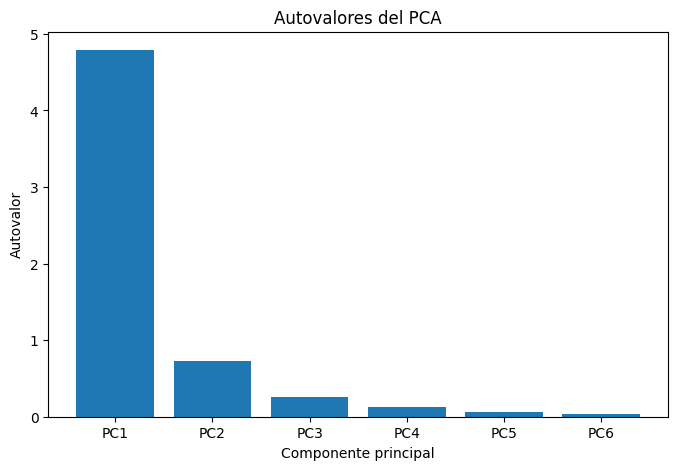

In [12]:
x = np.arange(1, len(eigvals) + 1)

plt.figure()
plt.bar(x, eigvals)
plt.xticks(x, [f'PC{i}' for i in x])
plt.xlabel('Componente principal')
plt.ylabel('Autovalor')
plt.title('Autovalores del PCA')
plt.show()


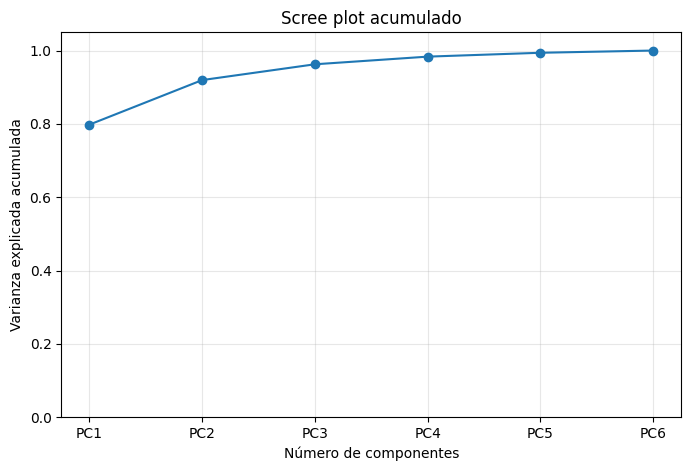

In [13]:
plt.figure()
plt.plot(x, cumulative_explained_variance, marker='o')
plt.xticks(x, [f'PC{i}' for i in x])
plt.ylim(0, 1.05)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Scree plot acumulado')
plt.grid(True, alpha=0.3)
plt.show()


## 9. Componentes principales y proyección de los datos

Si `V` contiene los autovectores por columnas, los scores se obtienen como:

\[
T = ZV
\]

donde cada columna de `T` es la proyección sobre una componente principal.


In [35]:
scores = Z.values @ eigvecs

scores_df = pd.DataFrame(
    scores,
    index=df_clean.index,
    columns=[f'PC{i}' for i in range(1, scores.shape[1] + 1)]
)
scores_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6
0,2.323002,0.571352,-0.288803,0.707256,0.040238,0.067944
1,3.201965,0.681870,-0.114558,0.181550,0.362482,-0.106457
2,2.666576,0.992744,-0.287299,0.462835,0.290003,0.035005
3,2.602139,0.621975,-0.063243,0.438304,0.409595,0.125719
4,2.596582,1.092197,-0.111405,0.678144,0.094696,0.135694


## 10. PCA con `sklearn` para validación

Esto debería dar los mismos autovalores/autovectores salvo cambios de signo o redondeo.


In [36]:
pca = PCA()
pca.fit(Z)

sk_summary = pd.DataFrame({
    'eigenvalue_sklearn': pca.explained_variance_,
    'explained_ratio_sklearn': pca.explained_variance_ratio_,
}, index=[f'PC{i}' for i in range(1, len(features) + 1)])

sk_summary


,eigenvalue_sklearn,explained_ratio_sklearn
PC1,4.788266,0.798044
PC2,0.728631,0.121439
PC3,0.258467,0.043078
PC4,0.125177,0.020863
PC5,0.063176,0.010529
PC6,0.036282,0.006047


In [37]:
comparison = pd.DataFrame({
    'manual_eigenvalue': eigvals,
    'sklearn_eigenvalue': pca.explained_variance_,
    'manual_ratio': explained_variance_ratio,
    'sklearn_ratio': pca.explained_variance_ratio_,
}, index=[f'PC{i}' for i in range(1, len(features) + 1)])

comparison


,manual_eigenvalue,sklearn_eigenvalue,manual_ratio,sklearn_ratio
PC1,4.788266,4.788266,0.798044,0.798044
PC2,0.728631,0.728631,0.121439,0.121439
PC3,0.258467,0.258467,0.043078,0.043078
PC4,0.125177,0.125177,0.020863,0.020863
PC5,0.063176,0.063176,0.010529,0.010529
PC6,0.036282,0.036282,0.006047,0.006047


## 11. Interpretación de las cargas (loadings)

Los autovectores indican cómo se combinan las variables originales en cada componente.

Valores grandes en valor absoluto implican mayor contribución a esa componente.


In [38]:
loadings = pd.DataFrame(
    eigvecs,
    index=features,
    columns=[f'PC{i}' for i in range(1, len(features) + 1)]
)
loadings


,PC1,PC2,PC3,PC4,PC5,PC6
Miles_per_Gallon,-0.398973,0.244835,-0.852111,-0.220809,-0.071094,0.031191
Cylinders,0.430615,-0.148314,-0.400323,0.576310,0.285904,0.467376
Displacement,0.443531,-0.108497,-0.297505,0.110783,-0.005594,-0.831081
Horsepower,0.434122,0.166158,-0.022600,-0.675237,0.558588,0.124312
Weight_in_lbs,0.430103,-0.286095,-0.124703,-0.340907,-0.726612,0.270975
Acceleration,-0.291926,-0.892652,-0.095281,-0.186210,0.270533,-0.031794


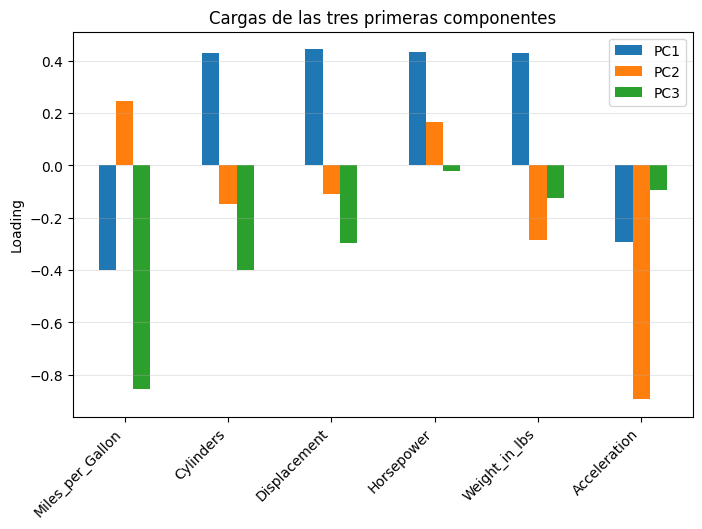

In [39]:
loadings[['PC1', 'PC2', 'PC3']].plot(kind='bar')
plt.title('Cargas de las tres primeras componentes')
plt.ylabel('Loading')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


## 12. Visualización en 1 dimensión

Proyectamos sobre `PC1`. Añadimos color por `Origin` para ver si aparece cierta estructura por procedencia.


In [41]:
meta = cars.loc[df_clean.index, ['Name', 'Origin', 'Year']].reset_index(drop=True)
plot_df = pd.concat([meta, scores_df], axis=1)
plot_df.head()


,Name,Origin,Year,PC1,PC2,PC3,PC4,PC5,PC6
0,chevrolet chevelle malibu,USA,1970-01-01,2.323002,0.571352,-0.288803,0.707256,0.040238,0.067944
1,buick skylark 320,USA,1970-01-01,3.201965,0.681870,-0.114558,0.181550,0.362482,-0.106457
2,plymouth satellite,USA,1970-01-01,2.666576,0.992744,-0.287299,0.462835,0.290003,0.035005
3,amc rebel sst,USA,1970-01-01,2.602139,0.621975,-0.063243,0.438304,0.409595,0.125719
4,ford torino,USA,1970-01-01,2.596582,1.092197,-0.111405,0.678144,0.094696,0.135694


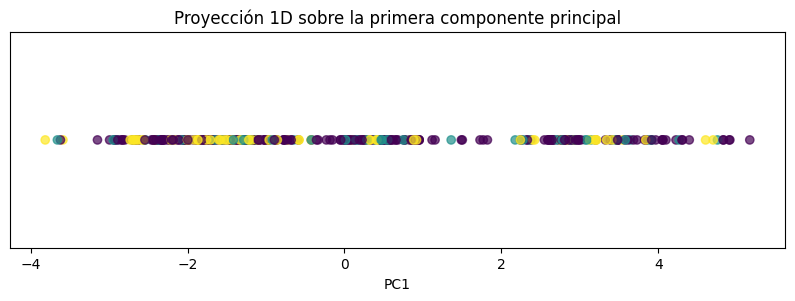

In [20]:
origins = plot_df['Origin'].dropna().unique()
origin_to_num = {origin: i for i, origin in enumerate(origins)}
colors = plot_df['Origin'].map(origin_to_num)

plt.figure(figsize=(10, 2.8))
plt.scatter(plot_df['PC1'], np.zeros(len(plot_df)), c=colors, alpha=0.7)
plt.yticks([])
plt.xlabel('PC1')
plt.title('Proyección 1D sobre la primera componente principal')
plt.show()


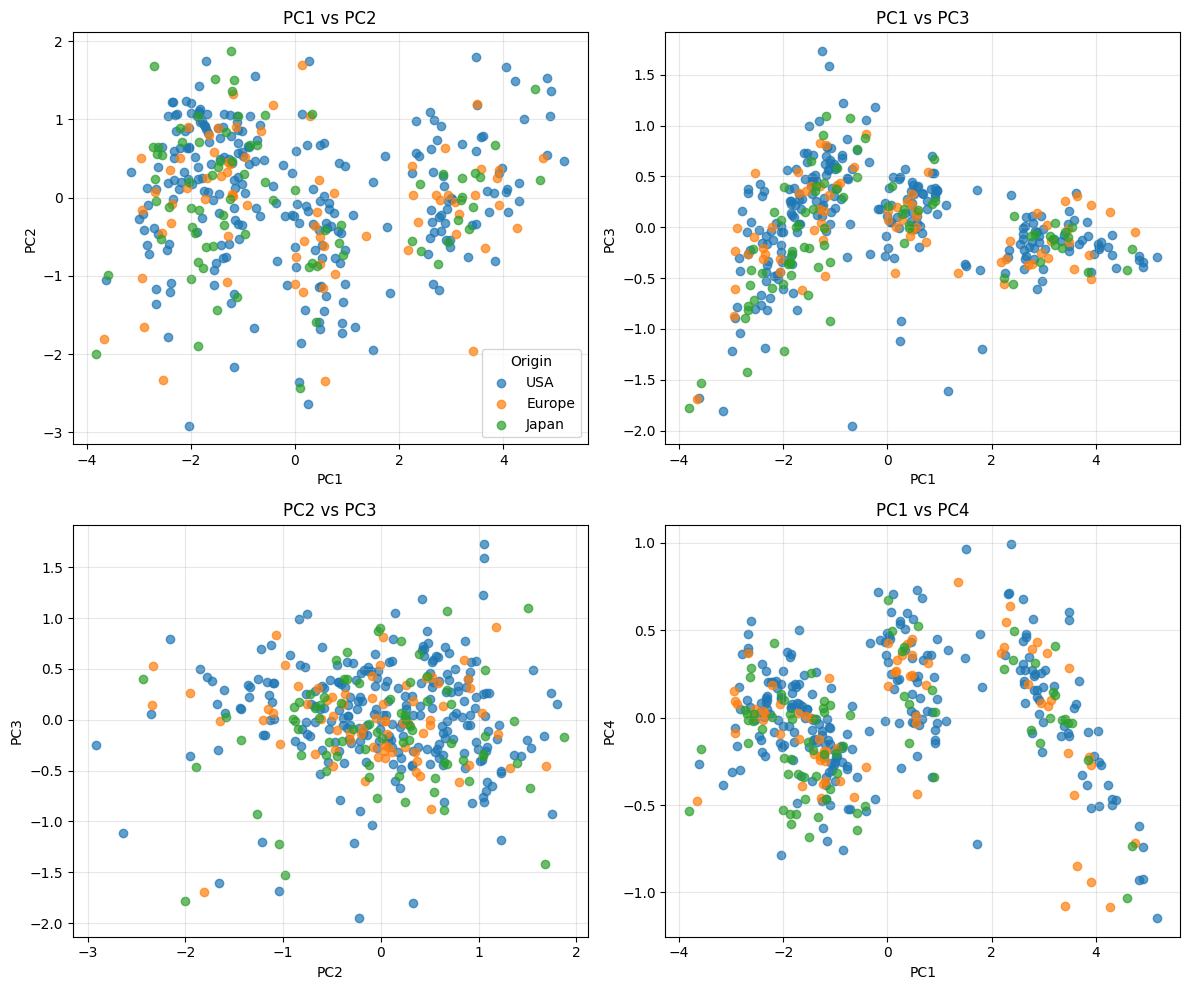

In [34]:
pairs = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3'), ('PC1', 'PC4')]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (xpc, ypc) in zip(axes, pairs):
    for origin in plot_df['Origin'].dropna().unique():
        mask = plot_df['Origin'] == origin
        ax.scatter(plot_df.loc[mask, xpc], plot_df.loc[mask, ypc], alpha=0.7, label=origin)
    ax.set_xlabel(xpc)
    ax.set_ylabel(ypc)
    ax.set_title(f'{xpc} vs {ypc}')
    ax.grid(True, alpha=0.3)

axes[0].legend(title='Origin')
plt.tight_layout()
plt.show()

c:\Users\A200156153\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\A200156153\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


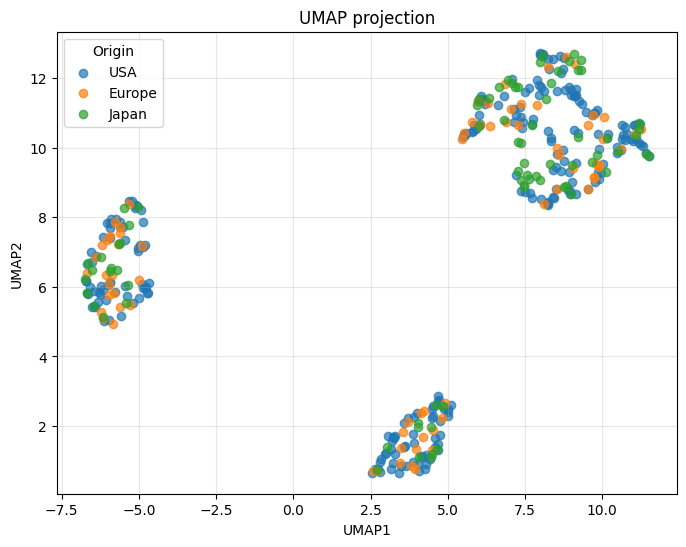

In [43]:
import umap

# UMAP sobre datos estandarizados (Z)
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(Z)

umap_df = pd.DataFrame(
    embedding,
    columns=['UMAP1', 'UMAP2'],
    index=df_clean.index
)

# añadir origen
umap_df['Origin'] = plot_df.loc[df_clean.index, 'Origin']

plt.figure(figsize=(8,6))

for origin in umap_df['Origin'].dropna().unique():
    mask = umap_df['Origin'] == origin
    plt.scatter(
        umap_df.loc[mask, 'UMAP1'],
        umap_df.loc[mask, 'UMAP2'],
        alpha=0.7,
        label=origin
    )

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP projection')
plt.legend(title='Origin')
plt.grid(alpha=0.3)
plt.show()

## 13. Visualización en 2 dimensiones

Ahora vemos `PC1` frente a `PC2`.


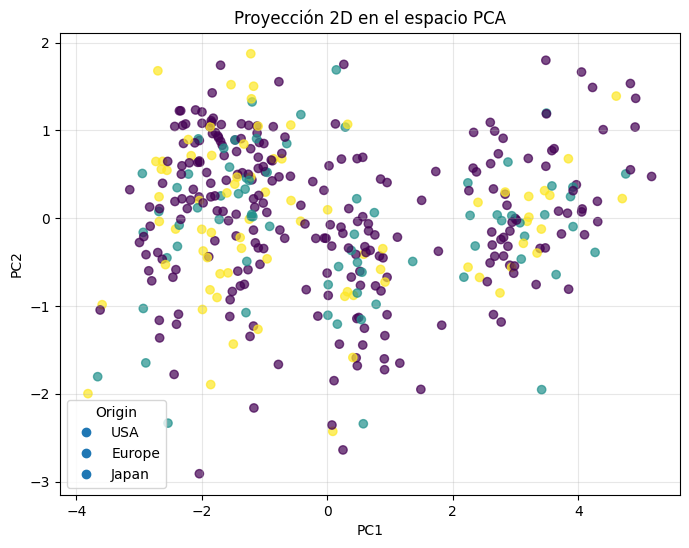

In [21]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(plot_df['PC1'], plot_df['PC2'], c=colors, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección 2D en el espacio PCA')

handles = []
for origin, idx in origin_to_num.items():
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='', label=origin))
plt.legend(handles=handles, title='Origin')
plt.grid(True, alpha=0.3)
plt.show()


## 14. Visualización en 3 dimensiones

Añadimos `PC3` para inspección visual más rica.


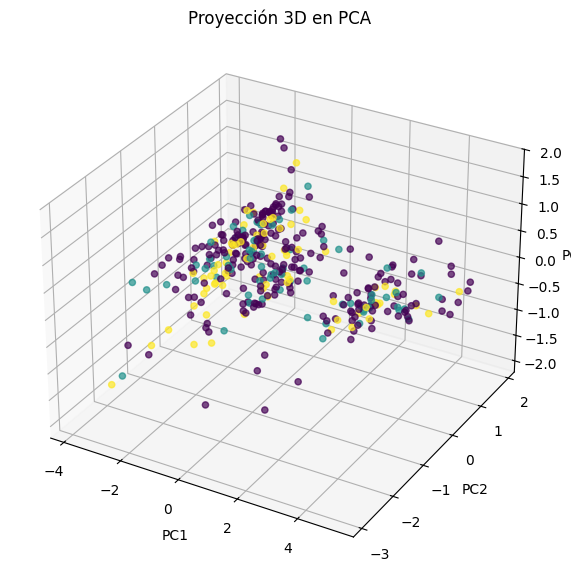

In [22]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(plot_df['PC1'], plot_df['PC2'], plot_df['PC3'], c=colors, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Proyección 3D en PCA')
plt.show()


## 15. Biplot sencillo (PC1 vs PC2)

Este gráfico mezcla:

- los **scores** de las observaciones,
- las **direcciones de las variables** originales a través de las cargas.

No es un biplot totalmente escalado en sentido estricto, pero sirve muy bien para intuición.


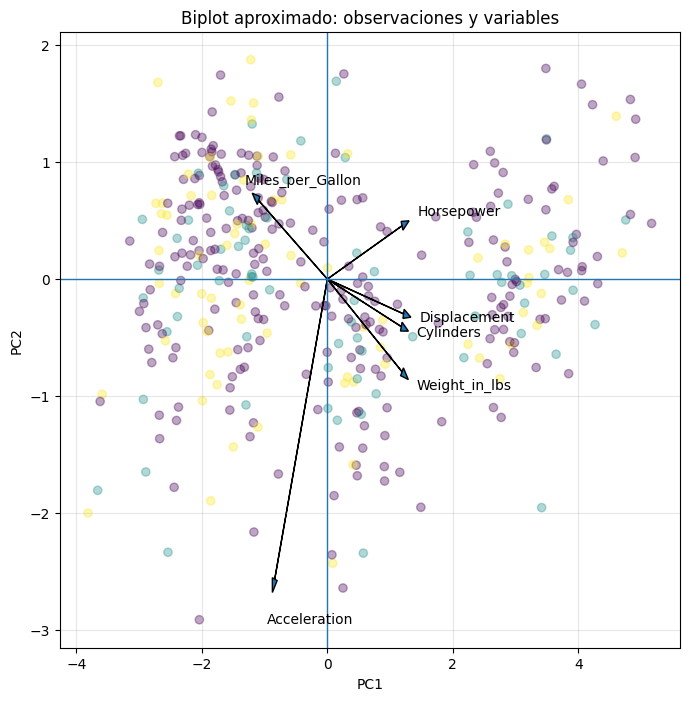

In [23]:
plt.figure(figsize=(8, 8))
plt.scatter(plot_df['PC1'], plot_df['PC2'], c=colors, alpha=0.35)

scale = 3.0
for feature in features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    plt.arrow(0, 0, x_loading, y_loading, head_width=0.08, length_includes_head=True)
    plt.text(x_loading * 1.1, y_loading * 1.1, feature)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot aproximado: observaciones y variables')
plt.grid(True, alpha=0.3)
plt.show()


## 16. Reconstrucción usando pocas componentes

Una idea clave de PCA es aproximar los datos originales usando pocas componentes.

Si usamos solo las `k` primeras componentes, obtenemos una versión comprimida del dataset.


In [24]:
k = 2

Vk = eigvecs[:, :k]
Tk = scores[:, :k]

# Reconstrucción en espacio estandarizado
Z_hat = Tk @ Vk.T

# Volvemos a escala original
X_hat = Z_hat * sigma.values + mu.values
X_hat_df = pd.DataFrame(X_hat, columns=features)

comparison_reconstruction = pd.concat(
    [df_clean.head(10).reset_index(drop=True), X_hat_df.head(10).add_suffix('_reconstructed')],
    axis=1
)
comparison_reconstruction


,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Miles_per_Gallon_reconstructed,Cylinders_reconstructed,Displacement_reconstructed,Horsepower_reconstructed,Weight_in_lbs_reconstructed,Acceleration_reconstructed
0,18.0,8,307.0,130.0,3504,12.0,17.303936,7.033720,295.742341,146.940550,3687.403558,12.263348
1,15.0,8,350.0,165.0,3693,11.5,14.778048,7.651390,335.282782,162.334718,3981.658690,11.283273
2,18.0,8,318.0,150.0,3436,11.0,17.039304,7.179479,306.904300,155.376692,3710.519037,10.948873
3,16.0,8,304.0,150.0,3433,12.0,16.531441,7.225950,308.123185,151.928664,3777.079304,11.913866
4,17.0,8,302.0,140.0,3449,10.5,17.447310,7.102906,302.526564,154.843176,3660.780331,10.760322
5,15.0,8,429.0,198.0,4341,10.0,11.686415,8.445446,386.974108,184.379480,4338.200676,9.514909
6,14.0,8,454.0,220.0,4354,9.0,10.756542,8.735362,406.945910,195.310878,4440.576277,8.219201
7,14.0,8,440.0,215.0,4312,8.5,11.341076,8.630874,401.125858,194.985671,4368.821183,7.871082
8,14.0,8,455.0,225.0,4425,10.0,10.160556,8.811290,410.229224,193.065733,4516.649893,9.031756
9,15.0,8,390.0,190.0,3850,8.5,14.016833,8.025596,363.486731,182.806868,4052.439717,8.176059


## 17. Error de reconstrucción según número de componentes

Esto ayuda a entender el compromiso entre compresión y pérdida de información.


In [25]:
reconstruction_errors = []

for k in range(1, len(features) + 1):
    Vk = eigvecs[:, :k]
    Tk = scores[:, :k]
    Z_hat_k = Tk @ Vk.T
    mse_k = np.mean((Z.values - Z_hat_k) ** 2)
    reconstruction_errors.append(mse_k)

reconstruction_df = pd.DataFrame({
    'n_components': range(1, len(features) + 1),
    'reconstruction_mse_on_scaled_space': reconstruction_errors,
})
reconstruction_df


,n_components,reconstruction_mse_on_scaled_space
0,1,2.014404e-01
1,2,8.031172e-02
2,3,3.734373e-02
3,4,1.653411e-02
4,5,6.031574e-03
5,6,3.435075e-31


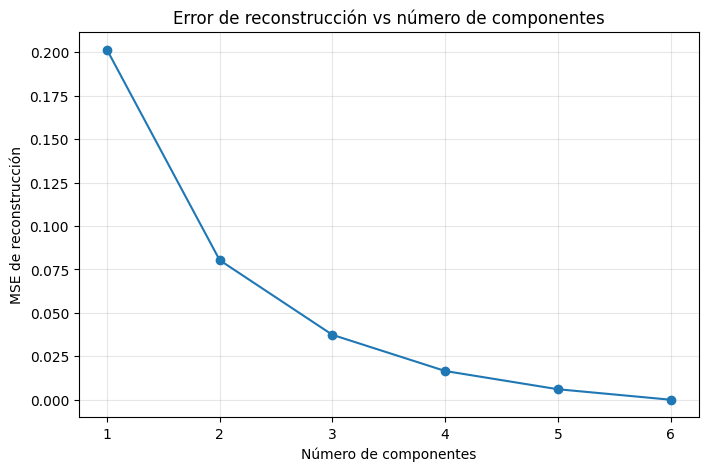

In [26]:
plt.figure()
plt.plot(reconstruction_df['n_components'], reconstruction_df['reconstruction_mse_on_scaled_space'], marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('MSE de reconstrucción')
plt.title('Error de reconstrucción vs número de componentes')
plt.grid(True, alpha=0.3)
plt.show()


## 18. Interpretación rápida esperable

Suele ocurrir algo parecido a esto:

- **PC1** captura tamaño/potencia del coche: cilindrada, caballos, peso y número de cilindros suelen ir en la misma dirección.
- `Miles_per_Gallon` suele ir en dirección opuesta a ese eje: coches más pesados y potentes tienden a consumir más.
- **PC2** y **PC3** suelen capturar matices adicionales, como diferencias entre aceleración y otras variables mecánicas.

Ejercicio útil: inspecciona los signos y magnitudes de `loadings[['PC1', 'PC2', 'PC3']]` y formula una interpretación propia.
